In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [134]:
df = pd.read_excel(r"C:\Users\Jorge Rivas\Documents\ANÁLISIS MES DE ENERO\RECOMPRA ENERO\VW\ARCOS\VENDIDOS ENE 26.xlsx")
df1 = pd.read_excel(r"C:\Users\Jorge Rivas\Documents\ANÁLISIS MES DE ENERO\RECOMPRA ENERO\VW\ARCOS\VENDIDOS 3 AÑOS.xlsx")

In [135]:
df.columns

Index(['Fecha', 'Serie S', 'Factura', 'Estatus Nota', 'N° Cliente', 'Cliente',
       'Lada', 'Telefono', 'Serie', 'Modelo/Placas', 'Nombre Modelo',
       'Valor  Factura', 'IVA', 'Isan', 'Valor Neto', 'Notas Credito',
       'Bonificacion', 'Valor Compra', 'Gastos Adicionales',
       'Venta Accesorios', 'Costo Accesorios', 'Margem Bruta', '% Marg',
       'TpVt', 'Nota Original', 'Fecha Factur  Original', 'Vendedor',
       'Responsable  Cancelacion', 'Canal', 'Tipo de Calle', 'Dirección',
       'Numero', 'Colonia', 'Municipio', 'CP', 'Estado', 'Año Modelo',
       'Nr Estoque', 'N° Cotización', 'Cod Pago', 'N° Motor', 'Versión',
       'Clave Vehiculo', 'Orden Servicio', 'Nombre Contacto', 'Lada.1',
       'Telefono 1', 'E_mail Contacto', 'Email Entidade', 'N° Proveedor',
       'Nombre Proveedor', 'Serie Factura de Compra',
       'Numero Factura de Compra', 'Fecha de Compra', 'ROI', '¿Entregado?',
       'Financiera', 'Fecha Entrega Unidad', 'Hora Entrega Unidad',
       'Folio 

# EXPLORACIÓN Y LIMPIEZA DE DATOS

In [136]:
df = df.dropna(subset='Serie')
df1 = df1.dropna(subset='Serie')
df = df.drop_duplicates(subset='Serie', keep='first')
df1 = df1.drop_duplicates(subset='Serie', keep='first')

In [137]:
print(df['Canal'].value_counts())

Canal
TRADICIONAL           41
LEASING               24
INTERCAMBIO            3
AUTOFINANCIAMIENTO     2
Name: count, dtype: int64


In [138]:
print(df1['Canal'].value_counts())

Canal
TRADICIONAL           323
LEASING               276
INTERCAMBIO            42
AUTOFINANCIAMIENTO      9
FLOTILLA                1
Name: count, dtype: int64


In [139]:
df = df[(df['Canal'] != 'INTERCAMBIO') & (df['Canal'] != 'FLOTILLA')].copy()
df1 = df1[(df1['Canal'] != 'INTERCAMBIO') & (df1['Canal'] != 'FLOTILLA')].copy()

In [140]:
print(df['Canal'].value_counts())

print(df1['Canal'].value_counts())

Canal
TRADICIONAL           41
LEASING               24
AUTOFINANCIAMIENTO     2
Name: count, dtype: int64
Canal
TRADICIONAL           323
LEASING               276
AUTOFINANCIAMIENTO      9
Name: count, dtype: int64


In [141]:
print(df['TpVt'].value_counts())

TpVt
T    41
L    24
A     2
Name: count, dtype: int64


In [142]:
print(df1['TpVt'].value_counts())

TpVt
T    323
L    276
A      9
Name: count, dtype: int64


In [143]:
print(df['Serie'].nunique())
print(df['Cliente'].nunique())

67
58


In [144]:
print(df1['Serie'].nunique())
print(df1['Cliente'].nunique())

608
493


In [145]:
df['Fecha'] = pd.to_datetime(df['Fecha'])
df1['Fecha'] = pd.to_datetime(df1['Fecha'])
print(df['Fecha'].min())
print(df['Fecha'].max())
print(df1['Fecha'].min())
print(df1['Fecha'].max())

2026-01-03 00:00:00
2026-01-31 00:00:00
2024-08-19 00:00:00
2025-12-31 00:00:00


# DIVISIÓN DE DATOS POR CLIENTE VENTAS DEL MES

In [146]:
df_cliente = df[['Serie', 'Cliente', 'Fecha', 'Nombre Modelo', 'Modelo/Placas', 'Canal']]
df_contacto = df[['Serie', 'Nombre Contacto', 'Fecha', 'Nombre Modelo', 'Modelo/Placas', 'Canal']]

In [147]:
df_cliente = df_cliente.sort_values(by=['Fecha', 'Cliente'])
df_cliente = df_cliente.dropna(subset='Cliente')
df_contacto = df_contacto.sort_values(by=['Fecha', 'Nombre Contacto'])
df_contacto = df_contacto.dropna(subset='Nombre Contacto')

In [148]:
print(df_cliente.shape)
df_cliente

(67, 6)


,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
0,3VVKP6B25TM036324,VOLKSWAGEN LEASING,2026-01-03,TAOS,CL22LZ,LEASING
5,3VWEP6BU1TM008675,CAPILLAS Y CEMENTERIOS DEL NORTE,2026-01-08,JETTA,BU53MS,TRADICIONAL
6,3VWEP6BU9TM019164,CAPILLAS Y CEMENTERIOS DEL NORTE,2026-01-08,JETTA,BU53MS,TRADICIONAL
1,9BWBH6DF8TT325507,ELIAS VAZQUEZ MEZA,2026-01-08,TERA,DF14D3,LEASING
4,WVW3C8CD3TW180643,HECTOR ALMAGUER CASTAÑEDA,2026-01-08,GOLF,DA19ZZ,TRADICIONAL
...,...,...,...,...,...,...
69,WVW3B4D29ST042047,LETICIA SOFIA PEREZ GONZALEZ,2026-01-31,VIRTUS,D223SY,TRADICIONAL
72,3VVHP6B28TM034075,MARIA JULIETA BASTIEN REYNA,2026-01-31,TAOS,CL23LZ,TRADICIONAL
71,WVG2C4CW8ST030951,MARIA MAGDALENA RODRIGUEZ MORALES,2026-01-31,TAIGUN,CW13NY,AUTOFINANCIAMIENTO
74,3VWSP6BU8SM093774,START BANREGIO S.A. DE C.V. SOFOM E.R. BANREGI...,2026-01-31,JETTA,BU53MS,TRADICIONAL


In [149]:
print(df_contacto.shape)
df_contacto

(18, 6)


,Serie,Nombre Contacto,Fecha,Nombre Modelo,Modelo/Placas,Canal
0,3VVKP6B25TM036324,ANA BERTHA ASCENCIO CABRAL,2026-01-03,TAOS,CL22LZ,LEASING
2,9BWKL45U4TP060206,ANA BERTHA ASCENCIO CABRAL,2026-01-08,SAVEIRO,5URNT4,LEASING
3,3VVAP6RM8TM051712,ANA BERTHA ASCENCIO CABRAL,2026-01-08,TIGUAN,RM12M7,LEASING
5,3VWEP6BU1TM008675,MARCO TULIO VALDEZ ALVAREZ,2026-01-08,JETTA,BU53MS,TRADICIONAL
6,3VWEP6BU9TM019164,MARCO TULIO VALDEZ ALVAREZ,2026-01-08,JETTA,BU53MS,TRADICIONAL
8,9BWKL45U0TP050692,JOSE FAJARDO,2026-01-09,SAVEIRO,5URNT4,LEASING
9,9BWKL45U2TP051746,JOSE FAJARDO,2026-01-09,SAVEIRO,5URNT4,LEASING
14,3VVHP6B29SM074227,ANA BERTHA ASCENCIO CABRAL,2026-01-13,TAOS,CL23LZ,LEASING
35,WVW3C8CD5SW260654,ANA BERTHA ASCENCIO CABRAL,2026-01-21,GOLF,NaN,LEASING
33,3VVJP6RM6TM048484,DIEGO ROBERTO CORTES DE ALBA,2026-01-21,TIGUAN,RM13M7,TRADICIONAL


In [150]:
cruce_df = set(df_cliente['Serie']) & set(df_contacto['Serie'])
df_cliente_limpio = df_cliente[~df_cliente['Serie'].isin(cruce_df)]
df_contacto_limpio = df_contacto[df_contacto['Serie'].isin(cruce_df)]

In [151]:
print(df_cliente_limpio.shape)
df_cliente_limpio

(49, 6)


,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
1,9BWBH6DF8TT325507,ELIAS VAZQUEZ MEZA,2026-01-08,TERA,DF14D3,LEASING
4,WVW3C8CD3TW180643,HECTOR ALMAGUER CASTAÑEDA,2026-01-08,GOLF,DA19ZZ,TRADICIONAL
10,1V2FE2CA8SC210938,CHRISTIAN SALDIVAR CAPETILLO,2026-01-09,CROSS SPORT,CMD5PR,LEASING
7,3VVHP6B20TM007498,RAMON ALEJANDRO AVILA AVIÑA,2026-01-09,TAOS,CL23LZ,TRADICIONAL
12,1V2FE2CA6TC204296,JANETTE AURORA RAMIREZ ANAYA,2026-01-10,CROSS SPORT,CMD5PR,TRADICIONAL
11,3VVHP6B24TM028404,MARIA GUADALUPE ROMO RODRIGUEZ,2026-01-10,TAOS,CL23LZ,LEASING
13,WVW3N4D24ST031187,SEBASTIAN DE LA TORRE TOPETE,2026-01-10,VIRTUS,D224NY,LEASING
15,3VWEP6BU5TM017282,CELY DEL REFUGIO RAMIREZ MARTINEZ,2026-01-13,JETTA,BU53MS,TRADICIONAL
17,WVW3C8CD9SW198594,IVAN AXEL RUIZ GUTIERREZ,2026-01-14,GOLF,NaN,LEASING
16,WVW3N4D28ST032231,VICTOR JAVIER GARCIA VELEZ,2026-01-14,VIRTUS,D224NY,TRADICIONAL


In [152]:
print(df_contacto_limpio.shape)
df_contacto_limpio

(18, 6)


,Serie,Nombre Contacto,Fecha,Nombre Modelo,Modelo/Placas,Canal
0,3VVKP6B25TM036324,ANA BERTHA ASCENCIO CABRAL,2026-01-03,TAOS,CL22LZ,LEASING
2,9BWKL45U4TP060206,ANA BERTHA ASCENCIO CABRAL,2026-01-08,SAVEIRO,5URNT4,LEASING
3,3VVAP6RM8TM051712,ANA BERTHA ASCENCIO CABRAL,2026-01-08,TIGUAN,RM12M7,LEASING
5,3VWEP6BU1TM008675,MARCO TULIO VALDEZ ALVAREZ,2026-01-08,JETTA,BU53MS,TRADICIONAL
6,3VWEP6BU9TM019164,MARCO TULIO VALDEZ ALVAREZ,2026-01-08,JETTA,BU53MS,TRADICIONAL
8,9BWKL45U0TP050692,JOSE FAJARDO,2026-01-09,SAVEIRO,5URNT4,LEASING
9,9BWKL45U2TP051746,JOSE FAJARDO,2026-01-09,SAVEIRO,5URNT4,LEASING
14,3VVHP6B29SM074227,ANA BERTHA ASCENCIO CABRAL,2026-01-13,TAOS,CL23LZ,LEASING
35,WVW3C8CD5SW260654,ANA BERTHA ASCENCIO CABRAL,2026-01-21,GOLF,NaN,LEASING
33,3VVJP6RM6TM048484,DIEGO ROBERTO CORTES DE ALBA,2026-01-21,TIGUAN,RM13M7,TRADICIONAL


In [153]:
df_contacto_limpio = df_contacto_limpio.rename(columns={'Nombre Contacto' : 'Cliente'})
df_contacto_limpio

,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
0,3VVKP6B25TM036324,ANA BERTHA ASCENCIO CABRAL,2026-01-03,TAOS,CL22LZ,LEASING
2,9BWKL45U4TP060206,ANA BERTHA ASCENCIO CABRAL,2026-01-08,SAVEIRO,5URNT4,LEASING
3,3VVAP6RM8TM051712,ANA BERTHA ASCENCIO CABRAL,2026-01-08,TIGUAN,RM12M7,LEASING
5,3VWEP6BU1TM008675,MARCO TULIO VALDEZ ALVAREZ,2026-01-08,JETTA,BU53MS,TRADICIONAL
6,3VWEP6BU9TM019164,MARCO TULIO VALDEZ ALVAREZ,2026-01-08,JETTA,BU53MS,TRADICIONAL
8,9BWKL45U0TP050692,JOSE FAJARDO,2026-01-09,SAVEIRO,5URNT4,LEASING
9,9BWKL45U2TP051746,JOSE FAJARDO,2026-01-09,SAVEIRO,5URNT4,LEASING
14,3VVHP6B29SM074227,ANA BERTHA ASCENCIO CABRAL,2026-01-13,TAOS,CL23LZ,LEASING
35,WVW3C8CD5SW260654,ANA BERTHA ASCENCIO CABRAL,2026-01-21,GOLF,NaN,LEASING
33,3VVJP6RM6TM048484,DIEGO ROBERTO CORTES DE ALBA,2026-01-21,TIGUAN,RM13M7,TRADICIONAL


In [154]:
tabla_cliente_df = pd.concat([df_cliente_limpio, df_contacto_limpio]).sort_values(by=['Fecha', 'Cliente'])
print(tabla_cliente_df.shape)
tabla_cliente_df

(67, 6)


,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
0,3VVKP6B25TM036324,ANA BERTHA ASCENCIO CABRAL,2026-01-03,TAOS,CL22LZ,LEASING
2,9BWKL45U4TP060206,ANA BERTHA ASCENCIO CABRAL,2026-01-08,SAVEIRO,5URNT4,LEASING
3,3VVAP6RM8TM051712,ANA BERTHA ASCENCIO CABRAL,2026-01-08,TIGUAN,RM12M7,LEASING
1,9BWBH6DF8TT325507,ELIAS VAZQUEZ MEZA,2026-01-08,TERA,DF14D3,LEASING
4,WVW3C8CD3TW180643,HECTOR ALMAGUER CASTAÑEDA,2026-01-08,GOLF,DA19ZZ,TRADICIONAL
...,...,...,...,...,...,...
75,1V2FE2CA2TC202464,JOSE ALFREDO LLAMAS IBARRA,2026-01-31,CROSS SPORT,CMD5PR,TRADICIONAL
76,WVG2C4CW2ST033909,JUAN IGNACIO MARTINEZ DE LA PEÑA,2026-01-31,TAIGUN,CW13NY,AUTOFINANCIAMIENTO
69,WVW3B4D29ST042047,LETICIA SOFIA PEREZ GONZALEZ,2026-01-31,VIRTUS,D223SY,TRADICIONAL
72,3VVHP6B28TM034075,MARIA JULIETA BASTIEN REYNA,2026-01-31,TAOS,CL23LZ,TRADICIONAL


# DIVISIÓN POR CLIENTE DE VENTAS HISTÓRICOS

In [155]:
df1_cliente = df1[['Serie', 'Cliente', 'Fecha', 'Nombre Modelo', 'Modelo/Placas', 'Canal']]
df1_contacto = df1[['Serie', 'Nombre Contacto', 'Fecha', 'Nombre Modelo', 'Modelo/Placas', 'Canal']]
df1_cliente = df1_cliente.dropna(subset='Cliente').sort_values(by=['Fecha', 'Cliente'])
df1_contacto = df1_contacto.dropna(subset='Nombre Contacto').sort_values(by=['Fecha', 'Nombre Contacto'])

In [156]:
print(df1_cliente.shape)
df1_cliente

(608, 6)


,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
0,1V2DR2CA5G1501491,VENTAS MOSTRADOR,2024-08-19,JETTA,163VJ6,TRADICIONAL
2,3VVVP65N2RM191621,JORGE ENRIQUE VILLA VEGA,2024-12-13,TIGUAN,BJ23N6,LEASING
3,3VWKP6BU7RM103138,SILVINO RUIZ VELASCO SEDANO,2024-12-14,JETTA,BU42LY,LEASING
4,WVW3C8CD9RW228476,GUILLERMO JESUS GUZMAN VELASCO,2024-12-16,GOLF,CD19UZ,TRADICIONAL
6,9BWAH5BZ7RT660091,ALEJANDRO AGUIRRE MEDRANO,2024-12-18,POLO,BZ32D3,LEASING
...,...,...,...,...,...,...
1031,9BWKL45U6TP049904,JEMA PACKAGING,2025-12-31,SAVEIRO,5URNT4,TRADICIONAL
1029,WVW3A4D23ST042497,JOSE ALEJANDRO MARTIN DEL CAMPO ULLOA,2025-12-31,VIRTUS,D223SV,TRADICIONAL
1023,WVW3C8CD1TW177644,SANTIAGO SANDOVAL GONZALEZ,2025-12-31,GOLF,DA19ZZ,LEASING
1021,WVW3N4D23ST045873,SELENE YANET PEREZ MUÑIZ,2025-12-31,VIRTUS,D224NY,TRADICIONAL


In [157]:
print(df1_contacto.shape)
df1_contacto

(129, 6)


,Serie,Nombre Contacto,Fecha,Nombre Modelo,Modelo/Placas,Canal
7,3VVJA65N2RM155203,JONATHAN ROBERTO QUEZADA,2024-12-18,TIGUAN,BJ24L0,TRADICIONAL
9,3VVJA65N4RM183391,OLIMPIA REYES GUTIERREZ,2024-12-20,TIGUAN,BJ24L0,LEASING
11,WV4FKPT10RS006313,ANA BERTHA ASCENCIO CABRAL,2024-12-23,AMAROK,T1BB34,LEASING
10,3VVHP6B28SM000989,JUAN CARLOS MAGAÑA HERNANDEZ,2024-12-23,TAOS,CL23LZ,TRADICIONAL
14,3VVVP65N8RM190330,ANA BERTHA ASCENCIO CABRAL,2024-12-24,TIGUAN,BJ23N6,LEASING
...,...,...,...,...,...,...
980,3VVJP6RM5TM023883,MARIA TERESA DE JESUS DOMINGUE,2025-12-12,TIGUAN,RM13M7,TRADICIONAL
1014,9BWKL45U0TP050952,RICARDO ORTIZ ALCANTAR,2025-12-30,SAVEIRO,5URNT4,TRADICIONAL
1027,9BWKL45U9TP053123,ANA BERTHA ASCENCIO CABRAL,2025-12-31,SAVEIRO,5URNT4,LEASING
1020,3VVJP6RM9TM034482,AZENETH RODRIGUEZ,2025-12-31,TIGUAN,RM13M7,TRADICIONAL


In [158]:
cruce_df1 = set(df1_cliente['Serie']) & set(df1_contacto['Serie'])
df1_cliente_limpio = df1_cliente[~df1_cliente['Serie'].isin(cruce_df1)]
df1_contacto_limpio = df1_contacto[df1_contacto['Serie'].isin(cruce_df1)]

In [159]:
print(df1_cliente_limpio.shape)
df1_cliente_limpio

(479, 6)


,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
0,1V2DR2CA5G1501491,VENTAS MOSTRADOR,2024-08-19,JETTA,163VJ6,TRADICIONAL
2,3VVVP65N2RM191621,JORGE ENRIQUE VILLA VEGA,2024-12-13,TIGUAN,BJ23N6,LEASING
3,3VWKP6BU7RM103138,SILVINO RUIZ VELASCO SEDANO,2024-12-14,JETTA,BU42LY,LEASING
4,WVW3C8CD9RW228476,GUILLERMO JESUS GUZMAN VELASCO,2024-12-16,GOLF,CD19UZ,TRADICIONAL
6,9BWAH5BZ7RT660091,ALEJANDRO AGUIRRE MEDRANO,2024-12-18,POLO,BZ32D3,LEASING
...,...,...,...,...,...,...
1034,9BWBH6DF5TT362742,FRANCISCO ALEJANDRO VACA SANCHEZ,2025-12-31,TERA,DF14D3,TRADICIONAL
1022,3VVKP6RM7TM053780,GUILLERMO ALONSO SOTO DELGADO,2025-12-31,TIGUAN,RM14M7,TRADICIONAL
1029,WVW3A4D23ST042497,JOSE ALEJANDRO MARTIN DEL CAMPO ULLOA,2025-12-31,VIRTUS,D223SV,TRADICIONAL
1023,WVW3C8CD1TW177644,SANTIAGO SANDOVAL GONZALEZ,2025-12-31,GOLF,DA19ZZ,LEASING


In [160]:
print(df1_contacto_limpio.shape)
df1_contacto_limpio

(129, 6)


,Serie,Nombre Contacto,Fecha,Nombre Modelo,Modelo/Placas,Canal
7,3VVJA65N2RM155203,JONATHAN ROBERTO QUEZADA,2024-12-18,TIGUAN,BJ24L0,TRADICIONAL
9,3VVJA65N4RM183391,OLIMPIA REYES GUTIERREZ,2024-12-20,TIGUAN,BJ24L0,LEASING
11,WV4FKPT10RS006313,ANA BERTHA ASCENCIO CABRAL,2024-12-23,AMAROK,T1BB34,LEASING
10,3VVHP6B28SM000989,JUAN CARLOS MAGAÑA HERNANDEZ,2024-12-23,TAOS,CL23LZ,TRADICIONAL
14,3VVVP65N8RM190330,ANA BERTHA ASCENCIO CABRAL,2024-12-24,TIGUAN,BJ23N6,LEASING
...,...,...,...,...,...,...
980,3VVJP6RM5TM023883,MARIA TERESA DE JESUS DOMINGUE,2025-12-12,TIGUAN,RM13M7,TRADICIONAL
1014,9BWKL45U0TP050952,RICARDO ORTIZ ALCANTAR,2025-12-30,SAVEIRO,5URNT4,TRADICIONAL
1027,9BWKL45U9TP053123,ANA BERTHA ASCENCIO CABRAL,2025-12-31,SAVEIRO,5URNT4,LEASING
1020,3VVJP6RM9TM034482,AZENETH RODRIGUEZ,2025-12-31,TIGUAN,RM13M7,TRADICIONAL


In [161]:
df1_contacto_limpio = df1_contacto_limpio.rename(columns={'Nombre Contacto' : 'Cliente'}).copy()
df1_contacto_limpio

,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
7,3VVJA65N2RM155203,JONATHAN ROBERTO QUEZADA,2024-12-18,TIGUAN,BJ24L0,TRADICIONAL
9,3VVJA65N4RM183391,OLIMPIA REYES GUTIERREZ,2024-12-20,TIGUAN,BJ24L0,LEASING
11,WV4FKPT10RS006313,ANA BERTHA ASCENCIO CABRAL,2024-12-23,AMAROK,T1BB34,LEASING
10,3VVHP6B28SM000989,JUAN CARLOS MAGAÑA HERNANDEZ,2024-12-23,TAOS,CL23LZ,TRADICIONAL
14,3VVVP65N8RM190330,ANA BERTHA ASCENCIO CABRAL,2024-12-24,TIGUAN,BJ23N6,LEASING
...,...,...,...,...,...,...
980,3VVJP6RM5TM023883,MARIA TERESA DE JESUS DOMINGUE,2025-12-12,TIGUAN,RM13M7,TRADICIONAL
1014,9BWKL45U0TP050952,RICARDO ORTIZ ALCANTAR,2025-12-30,SAVEIRO,5URNT4,TRADICIONAL
1027,9BWKL45U9TP053123,ANA BERTHA ASCENCIO CABRAL,2025-12-31,SAVEIRO,5URNT4,LEASING
1020,3VVJP6RM9TM034482,AZENETH RODRIGUEZ,2025-12-31,TIGUAN,RM13M7,TRADICIONAL


In [162]:
tabla_cliente_df1 = pd.concat([df1_cliente_limpio, df1_contacto_limpio]).sort_values(by=['Fecha', 'Cliente'])

In [163]:
print(tabla_cliente_df1.shape)
tabla_cliente_df1

(608, 6)


,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
0,1V2DR2CA5G1501491,VENTAS MOSTRADOR,2024-08-19,JETTA,163VJ6,TRADICIONAL
2,3VVVP65N2RM191621,JORGE ENRIQUE VILLA VEGA,2024-12-13,TIGUAN,BJ23N6,LEASING
3,3VWKP6BU7RM103138,SILVINO RUIZ VELASCO SEDANO,2024-12-14,JETTA,BU42LY,LEASING
4,WVW3C8CD9RW228476,GUILLERMO JESUS GUZMAN VELASCO,2024-12-16,GOLF,CD19UZ,TRADICIONAL
6,9BWAH5BZ7RT660091,ALEJANDRO AGUIRRE MEDRANO,2024-12-18,POLO,BZ32D3,LEASING
...,...,...,...,...,...,...
1022,3VVKP6RM7TM053780,GUILLERMO ALONSO SOTO DELGADO,2025-12-31,TIGUAN,RM14M7,TRADICIONAL
1031,9BWKL45U6TP049904,HORTENCIA ELIZARRAGA,2025-12-31,SAVEIRO,5URNT4,TRADICIONAL
1029,WVW3A4D23ST042497,JOSE ALEJANDRO MARTIN DEL CAMPO ULLOA,2025-12-31,VIRTUS,D223SV,TRADICIONAL
1023,WVW3C8CD1TW177644,SANTIAGO SANDOVAL GONZALEZ,2025-12-31,GOLF,DA19ZZ,LEASING


# CRUCE DE DATOS

In [164]:
repetidos = set(tabla_cliente_df['Cliente']) & set(tabla_cliente_df1['Cliente'])
repetidos_df = tabla_cliente_df[tabla_cliente_df['Cliente'].isin(repetidos)]
repetidos_df1 = tabla_cliente_df1[tabla_cliente_df1['Cliente'].isin(repetidos)]

In [165]:
print(repetidos_df['Cliente'].nunique())
print(repetidos_df1['Cliente'].nunique())

7
7


In [166]:
print(repetidos_df['Cliente'].value_counts())
print(repetidos_df['Canal'].value_counts())

Cliente
ANA BERTHA ASCENCIO CABRAL               7
JOSE FAJARDO                             2
IVAN AXEL RUIZ GUTIERREZ                 1
ADRIAN MALDONADO LOPEZ                   1
ALEJANDRA RIVAS GARCIA                   1
DIEGO ROBERTO CORTES DE ALBA             1
JOSE ALEJANDRO MARTIN DEL CAMPO ULLOA    1
Name: count, dtype: int64
Canal
LEASING        11
TRADICIONAL     3
Name: count, dtype: int64


In [167]:
print(repetidos_df1['Cliente'].value_counts())
print(repetidos_df1['Canal'].value_counts())

Cliente
ANA BERTHA ASCENCIO CABRAL               50
JOSE FAJARDO                              2
DIEGO ROBERTO CORTES DE ALBA              1
IVAN AXEL RUIZ GUTIERREZ                  1
ALEJANDRA RIVAS GARCIA                    1
ADRIAN MALDONADO LOPEZ                    1
JOSE ALEJANDRO MARTIN DEL CAMPO ULLOA     1
Name: count, dtype: int64
Canal
LEASING        49
TRADICIONAL     8
Name: count, dtype: int64


In [168]:
leasing_df = repetidos_df[repetidos_df['Canal'] == 'LEASING']
leasing_df = leasing_df.drop_duplicates(subset='Cliente', keep='first')
leasing_df

,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
0,3VVKP6B25TM036324,ANA BERTHA ASCENCIO CABRAL,2026-01-03,TAOS,CL22LZ,LEASING
8,9BWKL45U0TP050692,JOSE FAJARDO,2026-01-09,SAVEIRO,5URNT4,LEASING
17,WVW3C8CD9SW198594,IVAN AXEL RUIZ GUTIERREZ,2026-01-14,GOLF,NaN,LEASING
36,9BWAH5BZ1TT623125,ALEJANDRA RIVAS GARCIA,2026-01-21,POLO,NaN,LEASING


In [169]:
tradicional = repetidos_df[repetidos_df['Canal'] == 'TRADICIONAL']
tradicional = tradicional.drop_duplicates(subset='Cliente', keep='first')
tradicional

,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
24,9BWBH6DF1TT362673,ADRIAN MALDONADO LOPEZ,2026-01-16,TERA,NaN,TRADICIONAL
33,3VVJP6RM6TM048484,DIEGO ROBERTO CORTES DE ALBA,2026-01-21,TIGUAN,RM13M7,TRADICIONAL
77,WVW3A4D23ST042497,JOSE ALEJANDRO MARTIN DEL CAMPO ULLOA,2026-01-21,VIRTUS,NaN,TRADICIONAL


In [170]:
leasing_df1 = repetidos_df1[repetidos_df1['Canal'] == 'LEASING']
leasing_df1 = leasing_df1.drop_duplicates(subset='Cliente', keep='first')
leasing_df1

,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
11,WV4FKPT10RS006313,ANA BERTHA ASCENCIO CABRAL,2024-12-23,AMAROK,T1BB34,LEASING
564,9BWKL45U4SP070622,JOSE FAJARDO,2025-07-31,SAVEIRO,5URNT4,LEASING
722,WVW3C8CD9SW198594,IVAN AXEL RUIZ GUTIERREZ,2025-09-29,GOLF,DA19ZZ,LEASING
948,9BWAH5BZ1TT623125,ALEJANDRA RIVAS GARCIA,2025-11-27,POLO,BZ32D3,LEASING


In [171]:
tradicional_df1 = repetidos_df1[repetidos_df1['Canal'] == 'TRADICIONAL']
tradicional_df1 = tradicional_df1.drop_duplicates(subset='Cliente', keep='first')
tradicional_df1

,Serie,Cliente,Fecha,Nombre Modelo,Modelo/Placas,Canal
58,3VVHP65N8RM151007,ANA BERTHA ASCENCIO CABRAL,2025-01-21,TIGUAN,BJ23N6,TRADICIONAL
451,WVG2B4CWXST018223,DIEGO ROBERTO CORTES DE ALBA,2025-06-17,TAIGUN,CW13SY,TRADICIONAL
1008,9BWBH6DF1TT362673,ADRIAN MALDONADO LOPEZ,2025-12-27,TERA,DF14D3,TRADICIONAL
1029,WVW3A4D23ST042497,JOSE ALEJANDRO MARTIN DEL CAMPO ULLOA,2025-12-31,VIRTUS,D223SV,TRADICIONAL


In [172]:
cliente_real = tradicional['Cliente'].nunique()
print(f"Clientes reales que hicieron recompra: {cliente_real}")
clientes_unicos_mes = tabla_cliente_df['Cliente'].nunique()
print(f"Clientes únicos en el mes: {clientes_unicos_mes}")
prc_recompra = round((cliente_real / clientes_unicos_mes) * 100, 2)
print(f"Porcentaje de recompra real: {prc_recompra} %")

Clientes reales que hicieron recompra: 3
Clientes únicos en el mes: 58
Porcentaje de recompra real: 5.17 %


# GRAFICADO

Text(0.5, 1.0, 'Categorías de vendidos en el mes')

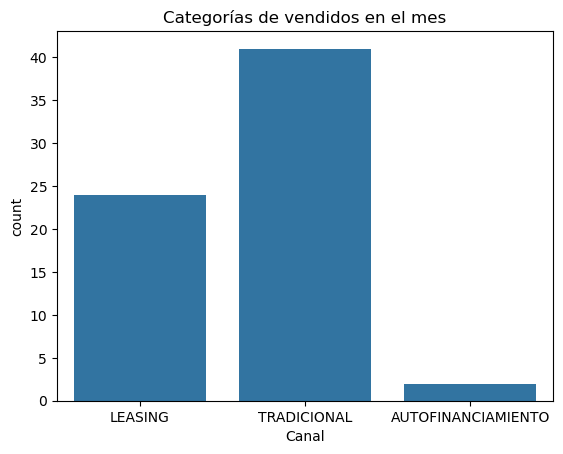

In [173]:
sns.countplot(
    data = tabla_cliente_df,
    x = 'Canal'

    
)
plt.title('Categorías de vendidos en el mes')

Text(0.5, 1.0, 'Categorías dentro de la recompra del mes')

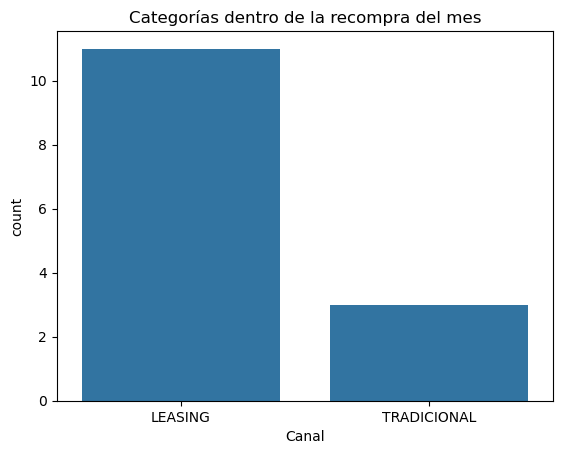

In [174]:
sns.countplot(
    data = repetidos_df,
    x = 'Canal'

)
plt.title('Categorías dentro de la recompra del mes')